In [29]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import talib
import pandas as pd
from pycaret.regression import *
import warnings
from datetime import date, datetime
warnings.filterwarnings('ignore')

In [30]:
# Download stock price data
def download(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    return stock_data

# Create technical indicators focusing on RSI and MACD
def create_technical_indicators(data):
    """Create RSI, MACD, and basic technical indicators"""
    df = data.copy()
    
    # Get the close price (handle multi-level columns)
    if isinstance(df.columns, pd.MultiIndex):
        close_prices = df['Close'].iloc[:, 0]  # Get first ticker's close price
    else:
        close_prices = df['Close']
    
    # RSI (Relative Strength Index) - Key indicator
    df['RSI'] = talib.RSI(close_prices, timeperiod=14)
    
    # MACD (Moving Average Convergence Divergence) - Key indicator
    macd, macd_signal, macd_hist = talib.MACD(close_prices, fastperiod=12, slowperiod=26, signalperiod=9)
    df['MACD'] = macd
    df['MACD_Signal'] = macd_signal
    df['MACD_Hist'] = macd_hist
    
    # Basic price features
    df['Price_Change'] = close_prices.pct_change()
    df['Price_Volatility'] = close_prices.rolling(window=10).std()
    
    # Simple Moving Averages for trend
    df['SMA_10'] = talib.SMA(close_prices, timeperiod=10)
    df['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
    
    return df

# Prepare data for machine learning with PyCaret
def prepare_ml_data(data, target_days_ahead=1):
    """Prepare data for machine learning focusing on RSI and MACD"""
    df = data.copy()
    
    # Get the close price for target
    if isinstance(df.columns, pd.MultiIndex):
        close_prices = df['Close'].iloc[:, 0]
    else:
        close_prices = df['Close']
    
    # Create target variable (future price)
    df['Target'] = close_prices.shift(-target_days_ahead)
    
    # Select key features focusing on RSI, MACD, and basic data
    feature_columns = [
        'RSI',           # RSI indicator
        'MACD',          # MACD line
        'MACD_Signal',   # MACD signal line
        'MACD_Hist',     # MACD histogram
        'Price_Change',  # Daily price change percentage
        'Price_Volatility', # Price volatility
        'SMA_10',        # Short-term moving average
        'SMA_20'         # Medium-term moving average
    ]
    
    # Add basic OHLC ratios
    if 'Open' in df.columns:
        if isinstance(df.columns, pd.MultiIndex):
            open_prices = df['Open'].iloc[:, 0]
            high_prices = df['High'].iloc[:, 0]
            low_prices = df['Low'].iloc[:, 0]
        else:
            open_prices = df['Open']
            high_prices = df['High']
            low_prices = df['Low']
            
        df['Open_Close_Ratio'] = open_prices / close_prices
        df['High_Low_Ratio'] = high_prices / low_prices
        feature_columns.extend(['Open_Close_Ratio', 'High_Low_Ratio'])
    
    # Create final dataset
    feature_columns.append('Target')
    ml_data = df[feature_columns].dropna()
    
    return ml_data

[*********************100%***********************]  1 of 1 completed



Downloaded 1377 days of data for GOOGL
Date range: 2020-01-02 to 2025-06-25

ML Dataset shape: (1343, 11)
Features: [('RSI', ''), ('MACD', ''), ('MACD_Signal', ''), ('MACD_Hist', ''), ('Price_Change', ''), ('Price_Volatility', ''), ('SMA_10', ''), ('SMA_20', ''), ('Open_Close_Ratio', ''), ('High_Low_Ratio', '')]
Target: ('Target', '')

Dataset Info:
Price           RSI         MACD  MACD_Signal    MACD_Hist Price_Change  \
Ticker                                                                    
count   1343.000000  1343.000000  1343.000000  1343.000000  1343.000000   
mean      53.379696     0.503392     0.499150     0.004242     0.000804   
std       11.084810     2.400276     2.251406     0.738152     0.020824   
min       24.952057    -7.050137    -5.948813    -2.420577    -0.116341   
25%       45.419886    -0.912707    -0.870405    -0.460556    -0.009857   
50%       54.374759     0.868573     0.836073     0.004197     0.001359   
75%       61.717893     2.145561     2.000629   

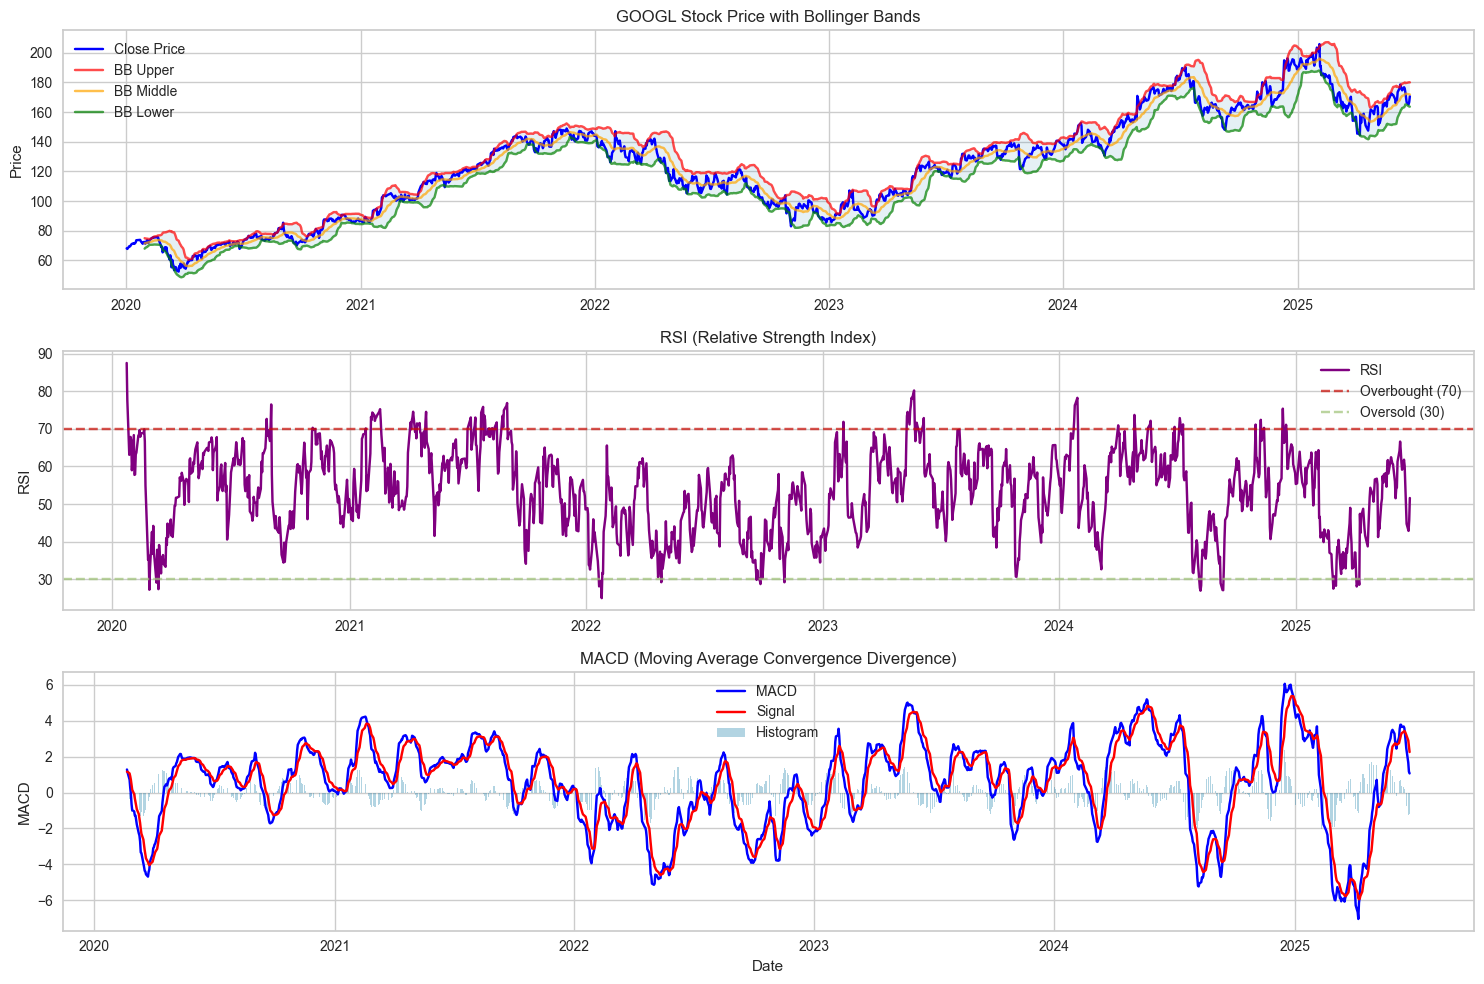

In [ ]:
# Download stock data
ticker = 'GOOGL'
start_date = '2020-01-01'
end_date = date.today().strftime('%Y-%m-%d') # Today's date
stock_data = download(ticker, start_date, end_date)

print(f"Downloaded {len(stock_data)} days of data for {ticker}")
print(f"Date range: {stock_data.index[0].date()} to {stock_data.index[-1].date()}")

# Create technical indicators
stock_data_with_indicators = create_technical_indicators(stock_data)

# Prepare data for machine learning
ml_data = prepare_ml_data(stock_data_with_indicators, target_days_ahead=1)

print(f"\nML Dataset shape: {ml_data.shape}")
print(f"Features: {list(ml_data.columns[:-1])}")
print(f"Target: {ml_data.columns[-1]}")

# Display basic statistics
print(f"\nDataset Info:")
print(ml_data.describe())

# Create Bollinger Bands for visualization
upper, middle, lower = talib.BBANDS(stock_data[("Close", "GOOGL")], timeperiod=20)

# Plot stock price and Bollinger Bands
plt.figure(figsize=(15, 10))

# Plot 1: Stock price with Bollinger Bands
plt.subplot(3, 1, 1)
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='blue')
plt.plot(stock_data.index, upper, label='BB Upper', color='red', alpha=0.7)
plt.plot(stock_data.index, middle, label='BB Middle', color='orange', alpha=0.7)
plt.plot(stock_data.index, lower, label='BB Lower', color='green', alpha=0.7)
plt.fill_between(stock_data.index, upper, lower, alpha=0.1)
plt.title(f'{ticker} Stock Price with Bollinger Bands')
plt.ylabel('Price')
plt.legend()

# Plot 2: RSI
plt.subplot(3, 1, 2)
plt.plot(stock_data_with_indicators.index, stock_data_with_indicators['RSI'], label='RSI', color='purple')
plt.axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought (70)')
plt.axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold (30)')
plt.title('RSI (Relative Strength Index)')
plt.ylabel('RSI')
plt.legend()

# Plot 3: MACD
plt.subplot(3, 1, 3)
plt.plot(stock_data_with_indicators.index, stock_data_with_indicators['MACD'], label='MACD', color='blue')
plt.plot(stock_data_with_indicators.index, stock_data_with_indicators['MACD_Signal'], label='Signal', color='red')
plt.bar(stock_data_with_indicators.index, stock_data_with_indicators['MACD_Hist'], label='Histogram', alpha=0.3)
plt.title('MACD (Moving Average Convergence Divergence)')
plt.ylabel('MACD')
plt.xlabel('Date')
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# Setup PyCaret environment
# Split data into train and test (80-20 split)
train_size = int(0.8 * len(ml_data))
train_data = ml_data.iloc[:train_size].copy()
test_data = ml_data.iloc[train_size:].copy()

# Flatten column names if they are multi-level
if isinstance(train_data.columns, pd.MultiIndex):
    train_data.columns = [col[0] if col[1] == '' else f"{col[0]}_{col[1]}" for col in train_data.columns]
    test_data.columns = [col[0] if col[1] == '' else f"{col[0]}_{col[1]}" for col in test_data.columns]

# Reset index to make it simpler
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

print(f"Training data: {len(train_data)} samples")
print(f"Testing data: {len(test_data)} samples")
print(f"Feature columns: {list(train_data.columns[:-1])}")

# Setup PyCaret regression environment
reg = setup(
    data=train_data, 
    target='Target',
    train_size=0.8,
    session_id=123
)

print("PyCaret environment setup completed!")

Training data: 1074 samples
Testing data: 269 samples
Feature columns: ['RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'Price_Change', 'Price_Volatility', 'SMA_10', 'SMA_20', 'Open_Close_Ratio', 'High_Low_Ratio']


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Regression
3,Original data shape,"(1074, 11)"
4,Transformed data shape,"(1074, 11)"
5,Transformed train set shape,"(859, 11)"
6,Transformed test set shape,"(215, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


PyCaret environment setup completed!


In [33]:
# Compare multiple models
print("Comparing different regression models...")
best_models = compare_models(
    include=['rf', 'et', 'gbr', 'lightgbm', 'lr', 'ridge', 'lasso'],
    sort='MAE',
    n_select=3,
    verbose=False
)

print(f"\nTop 3 models selected based on Mean Absolute Error")

# Train the best model
best_model = create_model(best_models[0])
print(f"\nBest model: {best_model}")

# Tune hyperparameters
tuned_model = tune_model(best_model, verbose=False)
print(f"\nModel after hyperparameter tuning completed!")

Comparing different regression models...

Top 3 models selected based on Mean Absolute Error

Top 3 models selected based on Mean Absolute Error


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.6764,5.4637,2.3375,0.9928,0.0222,0.0162
1,1.8450,5.5602,2.3580,0.9923,0.0229,0.0172
2,1.7660,5.3874,2.3211,0.9902,0.0228,0.0172
3,1.7414,8.1397,2.8530,0.9875,0.0238,0.0157
4,1.4892,3.6519,1.9110,0.9947,0.0202,0.0149
5,1.6614,4.7077,2.1697,0.9941,0.0191,0.0149
6,1.7456,5.1404,2.2672,0.9937,0.0215,0.0163
7,1.7685,5.2052,2.2815,0.9903,0.0204,0.0157
8,2.0519,7.8576,2.8031,0.9887,0.0255,0.0189



Best model: LinearRegression(n_jobs=-1)

Model after hyperparameter tuning completed!

Model after hyperparameter tuning completed!


In [34]:
# Example of using the trained model for prediction

# Finalize the model (trains on entire training dataset)
final_model = finalize_model(tuned_model)

# Make predictions on the test data
predictions = predict_model(final_model, data=test_data)

# Get the latest data for prediction
latest_data = ml_data.iloc[-1:].drop('Target', axis=1)
latest_prediction = predict_model(final_model, data=latest_data)

print(f"Latest stock data date: {stock_data.index[-1].date()}")
print(f"Current price: ${stock_data['Close'].iloc[-1, 0]:.2f}" if isinstance(stock_data.columns, pd.MultiIndex) else f"Current price: ${stock_data['Close'].iloc[-1]:.2f}")
print(f"Predicted next day price: ${latest_prediction['prediction_label'].iloc[0]:.2f}")

# Calculate prediction confidence
current_price = stock_data['Close'].iloc[-1, 0] if isinstance(stock_data.columns, pd.MultiIndex) else stock_data['Close'].iloc[-1]
predicted_price = latest_prediction['prediction_label'].iloc[0]
price_change = ((predicted_price - current_price) / current_price) * 100

print(f"Predicted price change: {price_change:+.2f}%")

if price_change > 0:
    recommendation = "BUY"
elif price_change < -2:
    recommendation = "SELL"
else:
    recommendation = "HOLD"

print(f"Recommendation: {recommendation}")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,2.7403,13.6812,3.6988,0.9162,0.0216,0.0161


Latest stock data date: 2025-06-25
Current price: $170.68
Predicted next day price: $167.34
Predicted price change: -1.95%
Recommendation: HOLD


Model Evaluation Results:


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…


Test Set Performance:
Mean Absolute Error: $2.74
Root Mean Squared Error: $3.70
R² Score: 0.9162
Directional Accuracy: 48.88%


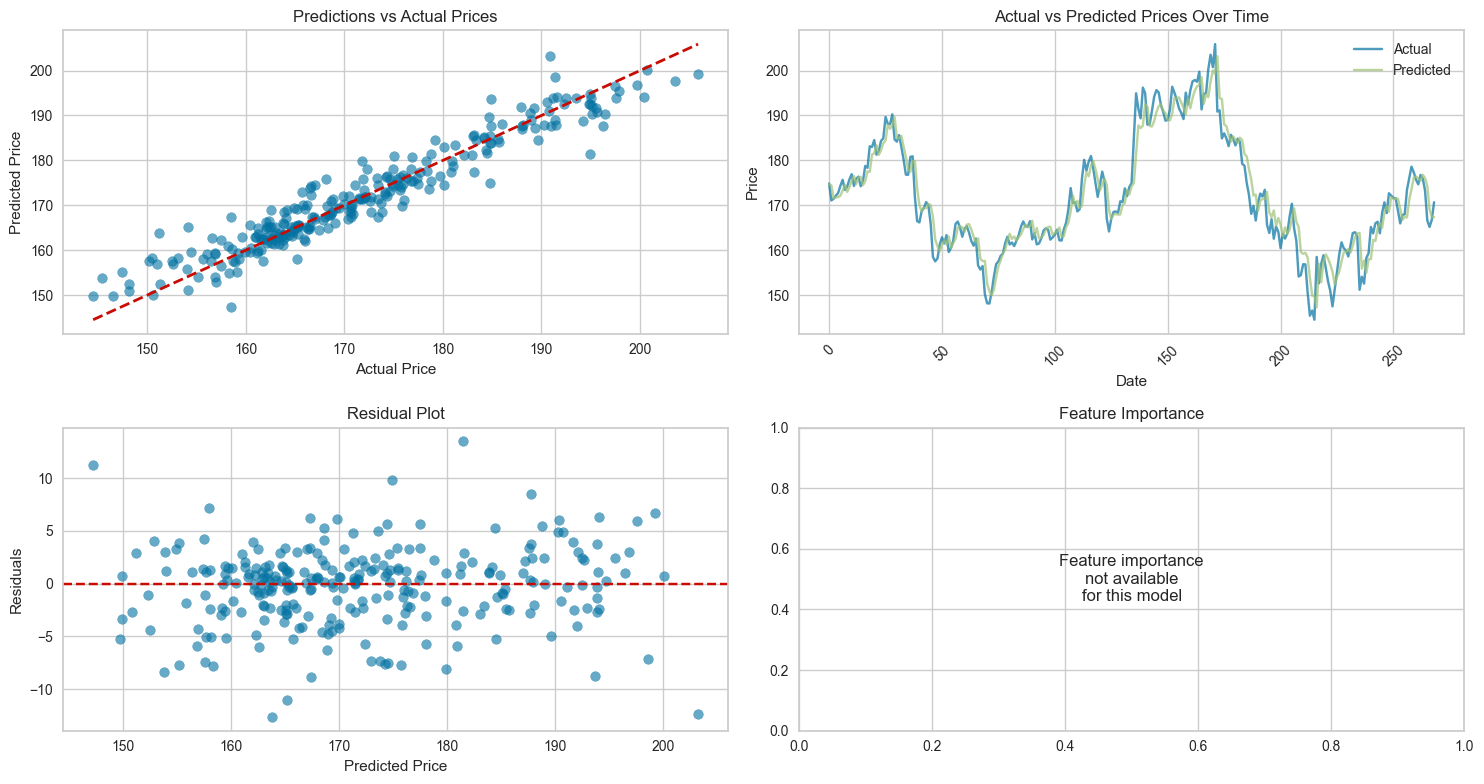


TRADING SIGNAL SUMMARY
Stock: GOOGL
Current Price: $170.68
Predicted Next Day Price: $167.34
Expected Change: -1.95%
Recommendation: HOLD
Model R² Score: 0.9162
Model Directional Accuracy: 48.88%


In [35]:
# Evaluate the model
print("Model Evaluation Results:")
print("=" * 50)

# Evaluate on test data
evaluate_model(final_model)

# Calculate additional metrics
test_predictions = predictions['prediction_label']
test_actual = predictions['Target']

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test_actual, test_predictions)
mse = mean_squared_error(test_actual, test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_actual, test_predictions)

print(f"\nTest Set Performance:")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Calculate directional accuracy
actual_direction = np.sign(test_actual.diff().dropna())
predicted_direction = np.sign(test_predictions.diff().dropna())
directional_accuracy = (actual_direction == predicted_direction).mean()
print(f"Directional Accuracy: {directional_accuracy:.2%}")

# Visualize predictions vs actual
plt.figure(figsize=(15, 8))

# Plot 1: Predictions vs Actual
plt.subplot(2, 2, 1)
plt.scatter(test_actual, test_predictions, alpha=0.6)
plt.plot([test_actual.min(), test_actual.max()], [test_actual.min(), test_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predictions vs Actual Prices')

# Plot 2: Time series of predictions
plt.subplot(2, 2, 2)
test_dates = test_data.index
plt.plot(test_dates, test_actual.values, label='Actual', alpha=0.7)
plt.plot(test_dates, test_predictions.values, label='Predicted', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices Over Time')
plt.legend()
plt.xticks(rotation=45)

# Plot 3: Residuals
plt.subplot(2, 2, 3)
residuals = test_actual - test_predictions
plt.scatter(test_predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# Plot 4: Feature importance (if available)
plt.subplot(2, 2, 4)
try:
    # Get feature importance
    feature_importance = final_model.feature_importances_
    feature_names = ml_data.columns[:-1]  # Exclude target
    
    # Sort features by importance
    indices = np.argsort(feature_importance)[::-1]
    
    plt.bar(range(len(feature_importance)), feature_importance[indices])
    plt.xticks(range(len(feature_importance)), [feature_names[i] for i in indices], rotation=45)
    plt.title('Feature Importance')
    plt.ylabel('Importance')
except:
    plt.text(0.5, 0.5, 'Feature importance\nnot available\nfor this model', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Feature Importance')

plt.tight_layout()
plt.show()

print(f"\n" + "="*50)
print("TRADING SIGNAL SUMMARY")
print("="*50)
print(f"Stock: {ticker}")
print(f"Current Price: ${current_price:.2f}")
print(f"Predicted Next Day Price: ${predicted_price:.2f}")
print(f"Expected Change: {price_change:+.2f}%")
print(f"Recommendation: {recommendation}")
print(f"Model R² Score: {r2:.4f}")
print(f"Model Directional Accuracy: {directional_accuracy:.2%}")
print("="*50)